<a href="https://colab.research.google.com/github/mercury0925/2026-1_CV/blob/main/CV_HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW#3 MLP 신경망 성능에 영향을 주는 요소별 실험과 분석

## 목차
- [0] 환경 설정 & 라이브러리 임포트
- [1] 공통 베이스라인 (데이터 로딩 / 모델 / 학습루프 / 시각화 유틸)
- [2] 실험 A — 손실함수 비교 (CrossEntropy vs MSE)
- [3] 실험 B — 활성화함수 비교 (ReLU vs LeakyReLU vs Sigmoid)
- [4] 실험 C — Optimizer 비교 (SGD / SGD+Momentum / Adam)

# [0] 환경 설정 & 라이브러리 임포트

In [1]:
import subprocess
subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)

# 기본 라이브러리
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import load_digits, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 실험 재현성을 위해 모든 난수 시드를 42로 고정
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# GPU 사용 가능 여부 확인
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 디바이스: {DEVICE}')

# 데이터셋별 에폭 수 (과제 가이드라인 기준)
# 실험 A, C → Digits Dataset → 20~50 범위에서 30으로 설정
# 실험 B → make_moons → 200~500 범위에서 300으로 설정
EPOCHS_DIGITS = 30
EPOCHS_MOONS  = 300
BATCH_SIZE    = 64

사용 디바이스: cuda


In [2]:
import os, glob
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

if not os.path.exists(font_path):
    print("폰트 파일 없음 — 바로 위 셀 먼저 실행 후 런타임 재시작 필요")
    plt.rcParams['font.family'] = 'DejaVu Sans'
else:
    cache_dir = os.path.join(os.path.expanduser('~'), '.cache', 'matplotlib')
    for f in glob.glob(os.path.join(cache_dir, 'fontlist-*.json')):
        os.remove(f)

    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family']        = 'NanumGothic'
    plt.rcParams['font.sans-serif']    = ['NanumGothic', 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False
    print(f"폰트 설정 완료: {plt.rcParams['font.family']}")

폰트 설정 완료: ['NanumGothic']


# [1] 공통 베이스라인

## 1-1. 데이터 로딩

In [3]:
# ── 실험 A, C 공통 데이터셋: Digits Dataset (scikit-learn) ──────────────────
# 8x8 픽셀 손글씨 숫자 이미지, 총 1797개, 클래스 10개
# 입력 64차원
digits   = load_digits()
X        = digits.data.astype(np.float32)   # (1797, 64)
y        = digits.target                     # (1797,)

# 평균 0, 표준편차 1로 정규화 → 학습 안정성 향상
scaler   = StandardScaler()
X        = scaler.fit_transform(X)

# 80% 학습 / 20% 테스트 분할
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=SEED)

dig_train_ds = TensorDataset(
    torch.tensor(X_tr, dtype=torch.float32),
    torch.tensor(y_tr, dtype=torch.long)
)
dig_test_ds  = TensorDataset(
    torch.tensor(X_te, dtype=torch.float32),
    torch.tensor(y_te, dtype=torch.long)
)

loader_dig_train = DataLoader(dig_train_ds, batch_size=BATCH_SIZE, shuffle=True)
loader_dig_test  = DataLoader(dig_test_ds,  batch_size=BATCH_SIZE, shuffle=False)

DIGITS_INPUT   = 64
DIGITS_CLASSES = 10
print(f'Digits Dataset  train: {len(dig_train_ds)}, test: {len(dig_test_ds)}')

# ── 실험 B 데이터셋: make_moons ──────────────────────────────────────────────
# 2D 비선형 이진분류 문제
# Dead ReLU, 활성화 분포, 결정 경계 시각화에 적합
# noise=0.2 로 약간의 노이즈 추가 → 너무 쉬운 문제 방지
X_m, y_m = make_moons(n_samples=1000, noise=0.2, random_state=SEED)
scaler_m  = StandardScaler()
X_m       = scaler_m.fit_transform(X_m).astype(np.float32)

X_m_tr, X_m_te, y_m_tr, y_m_te = train_test_split(X_m, y_m, test_size=0.2, random_state=SEED)

moons_train_ds = TensorDataset(torch.tensor(X_m_tr), torch.tensor(y_m_tr, dtype=torch.long))
moons_test_ds  = TensorDataset(torch.tensor(X_m_te), torch.tensor(y_m_te, dtype=torch.long))

loader_moons_train = DataLoader(moons_train_ds, batch_size=32, shuffle=True)
loader_moons_test  = DataLoader(moons_test_ds,  batch_size=32, shuffle=False)

MOONS_INPUT   = 2
MOONS_CLASSES = 2
print(f'make_moons  train: {len(moons_train_ds)}, test: {len(moons_test_ds)}')

Digits Dataset  train: 1437, test: 360
make_moons  train: 800, test: 200


## 1-2. MLP 모델 클래스

In [4]:
# ── MLP 모델 정의 ────────────────────────────────────────────────────────────
# activation 을 외부에서 주입받아 실험 B에서 ReLU/LeakyReLU/Sigmoid 로 교체 가능
# forward hook 으로 각 레이어 활성화 출력 저장 → 히스토그램, Dead ReLU 히트맵에 활용
# backward hook 으로 각 레이어 gradient 저장 → Gradient Flow 시각화에 활용
class MLP(nn.Module):
    def __init__(self, input_size, hidden_sizes, num_classes, activation=nn.ReLU()):
        super(MLP, self).__init__()

        self.activation      = activation
        self.layers          = nn.ModuleList()
        self.activations_out = {}  # 레이어별 활성화 출력 저장소
        self.gradients       = {}  # 레이어별 gradient 저장소

        # 은닉층 생성 (hidden_sizes 리스트 순서대로)
        in_size = input_size
        for h in hidden_sizes:
            self.layers.append(nn.Linear(in_size, h))
            in_size = h

        # 출력층 (활성화 함수 없이 logit 출력)
        self.output_layer = nn.Linear(in_size, num_classes)

    def forward(self, x):
        # 입력을 1D 벡터로 평탄화 (배치 차원 유지)
        # Digits 는 이미 64차원이라 평탄화 후에도 변화 없음
        x = x.view(x.size(0), -1)

        for idx, layer in enumerate(self.layers):
            x = layer(x)
            x = self.activation(x)
            # 각 레이어 활성화 결과 저장 (Dead ReLU 분석용)
            self.activations_out[f'layer{idx+1}'] = x.detach().cpu()

        return self.output_layer(x)

    def register_gradient_hooks(self):
        # weight gradient 를 backward 시 자동으로 저장하는 hook 등록
        def make_hook(name):
            def hook(grad):
                self.gradients[name] = grad.detach().cpu()
            return hook
        for idx, layer in enumerate(self.layers):
            layer.weight.register_hook(make_hook(f'layer{idx+1}_weight'))


def build_model(input_size, num_classes, hidden_sizes=[256, 128],
                activation=nn.ReLU(), weight_std=None):
    # 모델 생성 후 GPU/CPU 로 이동
    model = MLP(input_size, hidden_sizes, num_classes, activation).to(DEVICE)
    model.register_gradient_hooks()

    # weight_std 지정 시 가중치를 작은 값으로 초기화 → Dead ReLU 유도 (실험 B)
    if weight_std is not None:
        for layer in model.layers:
            nn.init.normal_(layer.weight, mean=0.0, std=weight_std)
            nn.init.zeros_(layer.bias)

    return model

# 정상 동작 확인
print(build_model(DIGITS_INPUT, DIGITS_CLASSES))

MLP(
  (activation): ReLU()
  (layers): ModuleList(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): Linear(in_features=256, out_features=128, bias=True)
  )
  (output_layer): Linear(in_features=128, out_features=10, bias=True)
)


## 1-3. 학습 루프 함수

In [5]:
# ── 공통 학습 루프 ───────────────────────────────────────────────────────────
# loss_fn, optimizer 를 인자로 받아 실험마다 교체 가능하도록 설계
# use_softmax_output=True → 실험 A MSELoss 사용 시 출력에 softmax 명시 적용
# model.eval() + torch.no_grad() → 평가 단계에서 dropout/batchnorm 비활성화 및
#                                   gradient 계산 생략 (메모리/속도 절약)
def train_model(model, train_loader, test_loader, loss_fn, optimizer,
                epochs, scheduler=None, use_softmax_output=False):

    history = {'train_loss': [], 'train_acc': [],
               'test_loss':  [], 'test_acc':  []}

    num_classes = model.output_layer.out_features

    for epoch in range(1, epochs + 1):

        # ── 학습 단계 ──────────────────────────────────────────────────────
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(inputs)

            if use_softmax_output:
                # MSELoss 는 확률값과 비교해야 하므로 softmax 먼저 적용
                # 타깃도 one-hot 벡터로 변환하여 동일한 형태로 맞춤
                outputs_for_loss = torch.softmax(outputs, dim=1)
                targets_onehot   = F.one_hot(labels, num_classes=num_classes).float()
                loss = loss_fn(outputs_for_loss, targets_onehot)
            else:
                # CrossEntropyLoss 는 내부적으로 log_softmax 포함 → logit 그대로 전달
                loss = loss_fn(outputs, labels)

            loss.backward()   # 역전파 (gradient 계산)
            optimizer.step()  # 파라미터 업데이트

            running_loss += loss.item() * inputs.size(0)
            correct      += (outputs.argmax(dim=1) == labels).sum().item()
            total        += inputs.size(0)

        train_loss = running_loss / total
        train_acc  = correct / total * 100

        # ── 평가 단계 ──────────────────────────────────────────────────────
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)

                if use_softmax_output:
                    outputs_for_loss = torch.softmax(outputs, dim=1)
                    targets_onehot   = F.one_hot(labels, num_classes=num_classes).float()
                    loss = loss_fn(outputs_for_loss, targets_onehot)
                else:
                    loss = loss_fn(outputs, labels)

                val_loss    += loss.item() * inputs.size(0)
                val_correct += (outputs.argmax(dim=1) == labels).sum().item()
                val_total   += inputs.size(0)

        val_loss = val_loss / val_total
        val_acc  = val_correct / val_total * 100

        # ExponentialLR 스케줄러 적용 (실험 C)
        if scheduler is not None:
            scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(val_loss)
        history['test_acc'].append(val_acc)

        # 진행 상황은 10 에폭마다 출력 (너무 잦은 출력 방지)
        if epoch % 10 == 0 or epoch == 1:
            lr_now = optimizer.param_groups[0]['lr']
            print(f'Epoch [{epoch:>3}/{epochs}]  '
                  f'Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.2f}%  '
                  f'Test Loss: {val_loss:.4f}  Test Acc: {val_acc:.2f}%  '
                  f'LR: {lr_now:.6f}')

    return history

## 1-4. 시각화 유틸 함수

In [6]:
# ── 시각화 유틸 ─────────────────────────────────────────────────────────────

def plot_learning_curves(histories, labels, title='학습 곡선'):
    # 여러 실험의 Test Loss / Test Accuracy 를 한 번에 비교
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    for hist, label in zip(histories, labels):
        ep = range(1, len(hist['train_loss']) + 1)
        axes[0].plot(ep, hist['test_loss'], label=label)
        axes[1].plot(ep, hist['test_acc'],  label=label)

    axes[0].set_title('Test Loss vs Epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].set_title('Test Accuracy vs Epoch')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


def plot_activation_distribution(model, loader, layer_names, title='활성화 분포'):
    # 한 배치를 forward 해서 레이어별 활성화 출력값 분포를 히스토그램으로 시각화
    # 출력이 0 에 몰릴수록 Dead ReLU / 양 극단에 몰릴수록 Sigmoid 포화 의심
    model.eval()
    with torch.no_grad():
        inputs, _ = next(iter(loader))
        _ = model(inputs.to(DEVICE))

    n = len(layer_names)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1: axes = [axes]
    fig.suptitle(title, fontsize=13, fontweight='bold')

    for ax, name in zip(axes, layer_names):
        vals = model.activations_out.get(name)
        if vals is None:
            ax.set_title(f'{name}: 없음')
            continue
        ax.hist(vals.numpy().flatten(), bins=50, color='steelblue', alpha=0.7)
        ax.set_title(f'{name} 활성화 분포')
        ax.set_xlabel('활성화 값')
        ax.set_ylabel('빈도')
        ax.grid(True)

    plt.tight_layout()
    plt.show()


def plot_dead_relu_heatmap(model, loader, title='Dead ReLU 히트맵'):
    # 전체 테스트셋 기준으로 각 뉴런이 Dead 상태인 비율을 히트맵으로 시각화
    # Dead ReLU : 활성화 출력이 0 이하 → gradient 도 0 → 학습에 기여 안 함
    model.eval()
    dead_counts, total_counts = {}, {}

    with torch.no_grad():
        for inputs, _ in loader:
            _ = model(inputs.to(DEVICE))
            for name, acts in model.activations_out.items():
                dead = (acts <= 0).float()
                dead_counts[name]  = dead_counts.get(name, 0) + dead.sum(0)
                total_counts[name] = total_counts.get(name, 0) + acts.shape[0]

    layer_names = sorted(dead_counts.keys())
    dead_ratios = [(dead_counts[n] / total_counts[n]).numpy() for n in layer_names]

    # 레이어마다 뉴런 수가 달라 최대 기준으로 패딩
    max_n  = max(r.shape[0] for r in dead_ratios)
    matrix = np.zeros((len(layer_names), max_n))
    for i, ratio in enumerate(dead_ratios):
        matrix[i, :ratio.shape[0]] = ratio

    fig, ax = plt.subplots(figsize=(min(max_n // 8 + 4, 20), 4))
    sns.heatmap(matrix, ax=ax, cmap='Reds', vmin=0, vmax=1,
                yticklabels=layer_names, cbar_kws={'label': 'Dead 비율'})
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('뉴런 인덱스')
    ax.set_ylabel('레이어')
    plt.tight_layout()
    plt.show()

    print('\n[레이어별 평균 Dead 뉴런 비율]')
    for name, ratio in zip(layer_names, dead_ratios):
        print(f'  {name}: {ratio.mean()*100:.2f}%')


def plot_gradient_flow(model, title='Gradient 흐름'):
    # 마지막 backward 이후 저장된 레이어별 gradient 의 L2 norm 을 바 차트로 시각화
    # norm 이 0 에 가까울수록 Vanishing / 매우 크면 Exploding 의심
    names = list(model.gradients.keys())
    norms = [model.gradients[n].norm().item() for n in names]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(names, norms, color='coral')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('레이어')
    ax.set_ylabel('Gradient L2 Norm')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y')
    plt.tight_layout()
    plt.show()


def convergence_epoch(loss_list, threshold=0.1):
    # loss 가 threshold 이하로 처음 내려간 epoch 반환
    # Digits 는 샘플 수가 적어 CE Loss 가 0.1 수준까지 떨어지는 경우 많음
    for i, l in enumerate(loss_list):
        if l <= threshold:
            return i + 1
    return '-'


def print_summary_table(rows, headers):
    # 정량 비교 결과를 콘솔에 표 형태로 출력
    col_widths = [max(len(str(r[i])) for r in [headers] + rows)
                  for i in range(len(headers))]
    fmt = '  '.join(f'{{:<{w}}}' for w in col_widths)
    print(fmt.format(*headers))
    print('  '.join('-' * w for w in col_widths))
    for row in rows:
        print(fmt.format(*[str(v) for v in row]))

print('유틸 함수 로딩 완료')

유틸 함수 로딩 완료


# [2] 실험 A — 손실함수 비교 (CrossEntropy vs MSE)

## 실험 목표
- CrossEntropyLoss 와 MSELoss 가 학습 성능에 미치는 차이 분석
- 수렴 속도, 최종 정확도, gradient 안정성 비교
- MSELoss 사용 시 Gradient Vanishing 여부 확인

**데이터셋** : Digits Dataset (8x8, 1797개)  
**고정 조건** : 동일 네트워크 (256→128→10), Optimizer=Adam(lr=0.001), Epoch=30  
**변경 조건** : 손실함수만 교체 (CrossEntropyLoss / MSELoss+softmax)

In [7]:
# 실험 A: 손실함수 비교 (CrossEntropy vs MSE)
# 손실함수만 교체, 나머지 조건(네트워크, optimizer, epoch) 동일 유지

# 학습 단계별 gradient 저장 기능이 추가된 학습 함수
# snapshots에 지정한 epoch에서 레이어별 gradient L2 norm 저장 → Q3 시각화용
def train_model_with_snapshots(model, train_loader, test_loader,
                                loss_fn, optimizer, epochs,
                                snapshots, snapshot_dict,
                                use_softmax_output=False):

    history = {'train_loss': [], 'train_acc': [],
               'test_loss':  [], 'test_acc':  []}
    num_classes = model.output_layer.out_features

    for epoch in range(1, epochs + 1):

        # 학습 단계
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)

            if use_softmax_output:
                # MSELoss: softmax 적용 후 one-hot 타깃과 비교
                outputs_for_loss = torch.softmax(outputs, dim=1)
                targets_onehot   = F.one_hot(labels, num_classes=num_classes).float()
                loss = loss_fn(outputs_for_loss, targets_onehot)
            else:
                # CrossEntropyLoss: 내부적으로 softmax 포함 → logit 그대로 전달
                loss = loss_fn(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            correct      += (outputs.argmax(dim=1) == labels).sum().item()
            total        += inputs.size(0)

        # 지정 epoch에서 gradient 저장 (epoch 1/15/30 → 초반/중반/후반)
        if epoch in snapshots:
            snapshot_dict[f'epoch{epoch}'] = {
                name: grad.norm().item()
                for name, grad in model.gradients.items()
            }

        # 평가 단계: model.eval() + torch.no_grad() 적용
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)

                if use_softmax_output:
                    outputs_for_loss = torch.softmax(outputs, dim=1)
                    targets_onehot   = F.one_hot(labels, num_classes=num_classes).float()
                    loss = loss_fn(outputs_for_loss, targets_onehot)
                else:
                    loss = loss_fn(outputs, labels)

                val_loss    += loss.item() * inputs.size(0)
                val_correct += (outputs.argmax(dim=1) == labels).sum().item()
                val_total   += inputs.size(0)

        val_loss = val_loss / val_total
        val_acc  = val_correct / val_total * 100

        history['train_loss'].append(running_loss / total)
        history['train_acc'].append(correct / total * 100)
        history['test_loss'].append(val_loss)
        history['test_acc'].append(val_acc)

        if epoch % 10 == 0 or epoch == 1:
            print(f'Epoch [{epoch:>3}/{epochs}]  '
                  f'Test Loss: {val_loss:.4f}  Test Acc: {val_acc:.2f}%')

    return history


# CrossEntropyLoss 학습
print('=' * 60)
print('실험 A: Digits — CrossEntropy Loss')
print('=' * 60)

grad_snapshots_ce = {}
model_ce   = build_model(DIGITS_INPUT, DIGITS_CLASSES)
loss_fn_ce = nn.CrossEntropyLoss()
opt_ce     = torch.optim.Adam(model_ce.parameters(), lr=0.001)

hist_ce = train_model_with_snapshots(
    model_ce, loader_dig_train, loader_dig_test,
    loss_fn=loss_fn_ce, optimizer=opt_ce,
    epochs=EPOCHS_DIGITS,
    snapshots=[1, 15, 30],
    snapshot_dict=grad_snapshots_ce,
    use_softmax_output=False
)

# MSELoss 학습 (softmax + one-hot 처리)
print()
print('=' * 60)
print('실험 A: Digits — MSE Loss (with softmax)')
print('=' * 60)

grad_snapshots_mse = {}
model_mse   = build_model(DIGITS_INPUT, DIGITS_CLASSES)
loss_fn_mse = nn.MSELoss()
opt_mse     = torch.optim.Adam(model_mse.parameters(), lr=0.001)

hist_mse = train_model_with_snapshots(
    model_mse, loader_dig_train, loader_dig_test,
    loss_fn=loss_fn_mse, optimizer=opt_mse,
    epochs=EPOCHS_DIGITS,
    snapshots=[1, 15, 30],
    snapshot_dict=grad_snapshots_mse,
    use_softmax_output=True
)

실험 A: Digits — CrossEntropy Loss
Epoch [  1/30]  Test Loss: 1.0620  Test Acc: 84.44%
Epoch [ 10/30]  Test Loss: 0.0866  Test Acc: 98.33%
Epoch [ 20/30]  Test Loss: 0.0890  Test Acc: 98.06%
Epoch [ 30/30]  Test Loss: 0.0920  Test Acc: 98.06%

실험 A: Digits — MSE Loss (with softmax)
Epoch [  1/30]  Test Loss: 0.0429  Test Acc: 76.67%
Epoch [ 10/30]  Test Loss: 0.0030  Test Acc: 98.61%
Epoch [ 20/30]  Test Loss: 0.0030  Test Acc: 98.06%
Epoch [ 30/30]  Test Loss: 0.0029  Test Acc: 98.06%


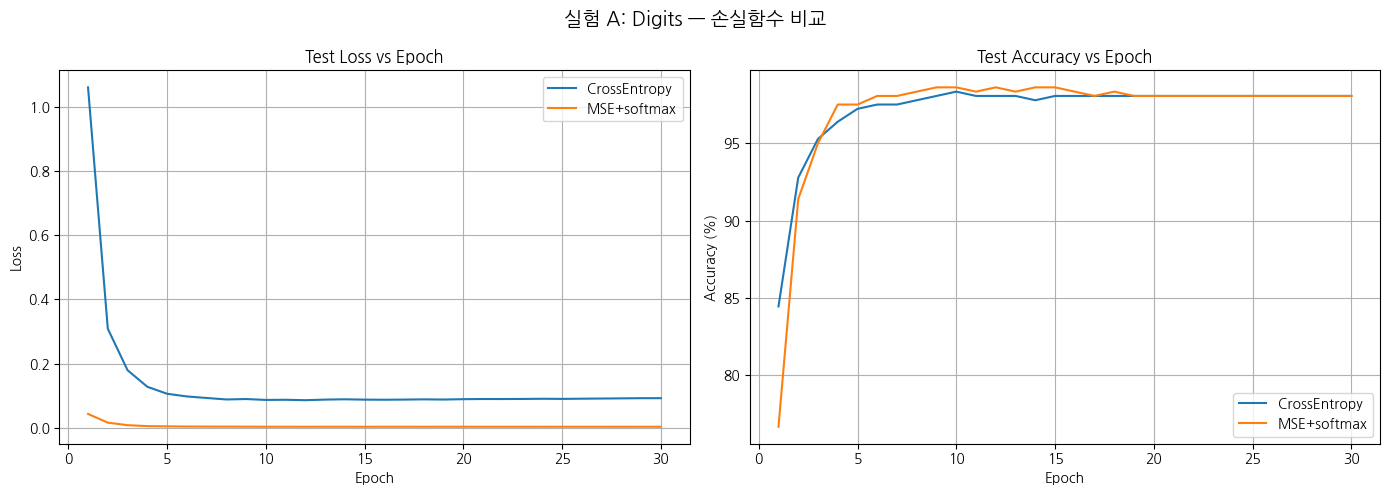

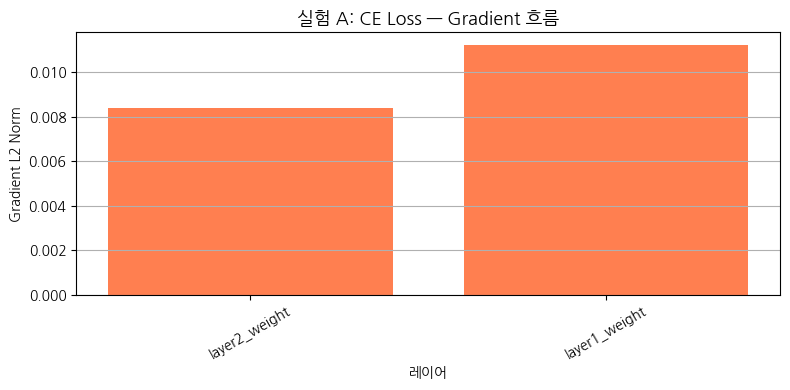

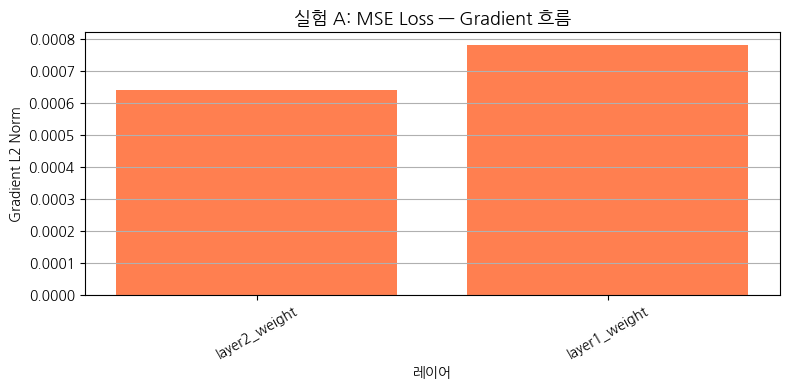

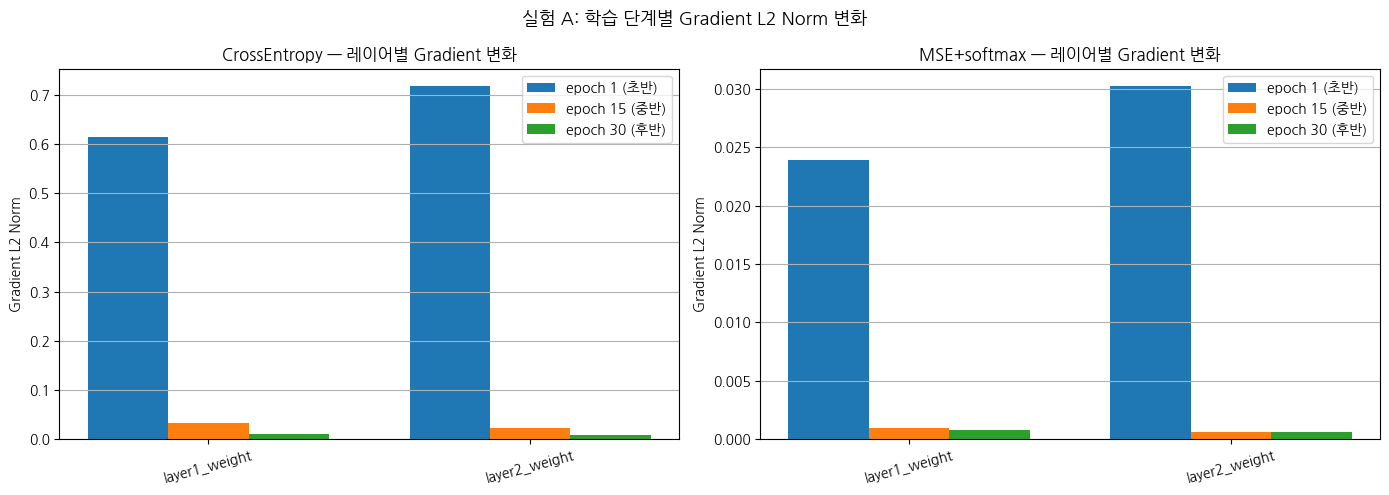


[실험 A 정량 비교 표]
손실함수          최종 정확도 (%)  Loss 최솟값  수렴 Epoch
------------  ----------  --------  --------
CrossEntropy  98.06       0.0858    6       
MSE+softmax   98.06       0.0029    1       


In [8]:
# 실험 A 시각화 및 정량 분석

# 1) Loss / Accuracy 학습 곡선 비교
plot_learning_curves(
    [hist_ce, hist_mse],
    ['CrossEntropy', 'MSE+softmax'],
    title='실험 A: Digits — 손실함수 비교'
)

# 2) 최종 시점 레이어별 gradient 흐름 (CE vs MSE 크기 비교)
plot_gradient_flow(model_ce,  title='실험 A: CE Loss — Gradient 흐름')
plot_gradient_flow(model_mse, title='실험 A: MSE Loss — Gradient 흐름')

# 3) 학습 단계별 gradient 변화 (초반/중반/후반)
# epoch 1 → 15 → 30으로 갈수록 gradient가 감소하는지 확인
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('실험 A: 학습 단계별 Gradient L2 Norm 변화', fontsize=13, fontweight='bold')

layer_names  = ['layer1_weight', 'layer2_weight']
epoch_keys   = ['epoch1', 'epoch15', 'epoch30']
epoch_labels = ['epoch 1 (초반)', 'epoch 15 (중반)', 'epoch 30 (후반)']
x     = np.arange(len(layer_names))
width = 0.25

for i, (ep_key, ep_label) in enumerate(zip(epoch_keys, epoch_labels)):
    vals_ce  = [grad_snapshots_ce.get(ep_key,  {}).get(l, 0) for l in layer_names]
    vals_mse = [grad_snapshots_mse.get(ep_key, {}).get(l, 0) for l in layer_names]
    axes[0].bar(x + i * width, vals_ce,  width, label=ep_label)
    axes[1].bar(x + i * width, vals_mse, width, label=ep_label)

for ax, title in zip(axes, ['CrossEntropy', 'MSE+softmax']):
    ax.set_title(f'{title} — 레이어별 Gradient 변화')
    ax.set_xticks(x + width)
    ax.set_xticklabels(layer_names, rotation=15)
    ax.set_ylabel('Gradient L2 Norm')
    ax.legend()
    ax.grid(axis='y')

plt.tight_layout()
plt.show()

# 4) 정량 비교 표
rows_A = [
    ['CrossEntropy',
     f"{hist_ce['test_acc'][-1]:.2f}",
     f"{min(hist_ce['test_loss']):.4f}",
     convergence_epoch(hist_ce['test_loss'])],
    ['MSE+softmax',
     f"{hist_mse['test_acc'][-1]:.2f}",
     f"{min(hist_mse['test_loss']):.4f}",
     convergence_epoch(hist_mse['test_loss'])],
]
print('\n[실험 A 정량 비교 표]')
print_summary_table(rows_A, ['손실함수', '최종 정확도 (%)', 'Loss 최솟값', '수렴 Epoch'])

# [3] 실험 B — 활성화함수 비교 (ReLU vs LeakyReLU vs Sigmoid)

## 실험 목표
- ReLU / LeakyReLU / Sigmoid 의 학습 영향 분석
- weight_std=0.01 로 초기값을 작게 설정 → Dead ReLU 유도
- LeakyReLU 가 Dead ReLU 를 얼마나 완화하는지 히트맵으로 확인
- Sigmoid 의 Vanishing Gradient 발생 구간 확인

**데이터셋** : make_moons (2D 비선형 이진분류, 레이어 출력 분포와 Dead ReLU 시각화에 적합)  
**고정 조건** : CrossEntropy Loss, Adam(lr=0.001), Epoch=300, weight_std=0.01  
**변경 조건** : 활성화함수만 교체

In [ ]:
# 실험 B: 활성화함수 비교 (ReLU vs LeakyReLU vs Sigmoid)
# 활성화함수만 교체, 나머지 조건 동일 유지
# weight_std=0.01로 초기화 → Dead ReLU 유도 조건

def get_activation(name):
    # 매 루프마다 새 객체 생성 (모델 간 객체 공유 방지)
    if name == 'ReLU':      return nn.ReLU()
    if name == 'LeakyReLU': return nn.LeakyReLU(negative_slope=0.01)
    if name == 'Sigmoid':   return nn.Sigmoid()

histories_B     = {}
models_B        = {}
# 공통 Q3: 초반/중반/후반 활성화 분포 비교용 snapshot
# epoch 1(초반), 150(중반), 300(후반) 시점의 레이어별 활성화 출력값 저장
act_snapshots_B = {}

for act_name in ['ReLU', 'LeakyReLU', 'Sigmoid']:
    print('=' * 60)
    print(f'실험 B: make_moons — {act_name}')
    print('=' * 60)

    model_b = build_model(
        MOONS_INPUT, MOONS_CLASSES,
        hidden_sizes=[256, 128],
        activation=get_activation(act_name),
        weight_std=0.01
    )
    opt_b     = torch.optim.Adam(model_b.parameters(), lr=0.001)
    loss_ce   = nn.CrossEntropyLoss()
    snap_epochs = {1: {}, 150: {}, 300: {}}

    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
    num_classes = model_b.output_layer.out_features

    for epoch in range(1, EPOCHS_MOONS + 1):
        model_b.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in loader_moons_train:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            opt_b.zero_grad()
            outputs = model_b(inputs)
            loss    = loss_ce(outputs, labels)
            loss.backward()
            opt_b.step()
            running_loss += loss.item() * inputs.size(0)
            correct      += (outputs.argmax(dim=1) == labels).sum().item()
            total        += inputs.size(0)

        # 지정 epoch에서 활성화 분포 저장 (Q3 초반/중반/후반 비교용)
        if epoch in snap_epochs:
            model_b.eval()
            with torch.no_grad():
                inp, _ = next(iter(loader_moons_test))
                _      = model_b(inp.to(DEVICE))
            snap_epochs[epoch] = {
                k: v.numpy().flatten().copy()
                for k, v in model_b.activations_out.items()
            }

        model_b.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in loader_moons_test:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs  = model_b(inputs)
                loss     = loss_ce(outputs, labels)
                val_loss    += loss.item() * inputs.size(0)
                val_correct += (outputs.argmax(dim=1) == labels).sum().item()
                val_total   += inputs.size(0)

        val_loss = val_loss / val_total
        val_acc  = val_correct / val_total * 100
        history['train_loss'].append(running_loss / total)
        history['train_acc'].append(correct / total * 100)
        history['test_loss'].append(val_loss)
        history['test_acc'].append(val_acc)

        if epoch % 50 == 0 or epoch == 1:
            print(f'Epoch [{epoch:>3}/{EPOCHS_MOONS}]  '
                  f'Test Loss: {val_loss:.4f}  Test Acc: {val_acc:.2f}%')

    histories_B[act_name]     = history
    models_B[act_name]        = model_b
    act_snapshots_B[act_name] = snap_epochs
    print()


실험 B: make_moons — ReLU
Epoch [  1/300]  Test Loss: 0.4190  Test Acc: 82.50%
Epoch [ 50/300]  Test Loss: 0.0559  Test Acc: 97.50%
Epoch [100/300]  Test Loss: 0.0402  Test Acc: 99.00%
Epoch [150/300]  Test Loss: 0.0434  Test Acc: 97.50%


In [ ]:
# 실험 B 시각화 및 정량 분석

# 1) Loss / Accuracy 학습 곡선 비교
plot_learning_curves(
    list(histories_B.values()),
    list(histories_B.keys()),
    title='실험 B: make_moons — 활성화함수 비교'
)

# 2) 레이어별 활성화 출력 분포 히스토그램 (최종 상태)
# 0에 집중 → Dead ReLU / 양 극단 집중 → Sigmoid 포화
for act_name, model_b in models_B.items():
    plot_activation_distribution(
        model_b, loader_moons_test,
        layer_names=['layer1', 'layer2'],
        title=f'실험 B: {act_name} — 레이어별 활성화 분포'
    )

# 3) Dead ReLU 히트맵 (ReLU vs LeakyReLU)
for act_name in ['ReLU', 'LeakyReLU']:
    plot_dead_relu_heatmap(
        models_B[act_name], loader_moons_test,
        title=f'실험 B: {act_name} — Dead 뉴런 히트맵'
    )

# 4) Gradient 흐름 비교 (Sigmoid vanishing 구간 확인)
for act_name, model_b in models_B.items():
    plot_gradient_flow(model_b, title=f'실험 B: {act_name} — Gradient 흐름')

# 5) Sigmoid vanishing gradient 구간 시각화
x_vals    = np.linspace(-10, 10, 300)
sigmoid   = 1 / (1 + np.exp(-x_vals))
sigmoid_d = sigmoid * (1 - sigmoid)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('실험 B: Sigmoid 포화 구간과 Vanishing Gradient', fontsize=13, fontweight='bold')

axes[0].plot(x_vals, sigmoid, color='steelblue')
axes[0].axhspan(0, 0.1,  alpha=0.15, color='red',    label='포화 구간 (출력 ≈ 0)')
axes[0].axhspan(0.9, 1.0, alpha=0.15, color='orange', label='포화 구간 (출력 ≈ 1)')
axes[0].set_title('Sigmoid 출력')
axes[0].set_xlabel('입력값 x')
axes[0].set_ylabel('출력값')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(x_vals, sigmoid_d, color='coral')
axes[1].axhline(y=0.01, color='red', linestyle='--', label='gradient ≈ 0 기준선')
axes[1].fill_between(x_vals, sigmoid_d, 0,
                     where=(sigmoid_d < 0.01),
                     alpha=0.3, color='red', label='Vanishing 구간')
axes[1].set_title('Sigmoid 도함수 (gradient 크기)')
axes[1].set_xlabel('입력값 x')
axes[1].set_ylabel('도함수 값')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# 6) 공통 Q3: 초반/중반/후반 활성화 분포 변화 (ReLU vs Sigmoid)
# epoch 1 → 150 → 300 으로 갈수록 분포가 어떻게 변하는지 비교
epoch_label_map = {1: 'epoch 1 (초반)', 150: 'epoch 150 (중반)', 300: 'epoch 300 (후반)'}

for act_name in ['ReLU', 'Sigmoid']:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(f'실험 B: {act_name} — 학습 단계별 활성화 분포 변화 (공통 Q3)', fontsize=13, fontweight='bold')

    for col, ep in enumerate([1, 150, 300]):
        snap = act_snapshots_B[act_name].get(ep, {})
        for row, lname in enumerate(['layer1', 'layer2']):
            ax   = axes[row][col]
            vals = snap.get(lname)
            if vals is not None:
                ax.hist(vals, bins=50, color='steelblue', alpha=0.7)
            ax.set_title(f'{lname} — {epoch_label_map[ep]}')
            ax.set_xlabel('활성화 값')
            ax.set_ylabel('빈도')
            ax.grid(True)

    plt.tight_layout()
    plt.show()

# 7) 레이어별 학습 기여도 히트맵 (세 활성화함수 한 번에 비교)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('실험 B: 활성화함수별 레이어 학습 기여도 (Dead 뉴런 비율)', fontsize=13, fontweight='bold')

for ax, act_name in zip(axes, ['ReLU', 'LeakyReLU', 'Sigmoid']):
    model_b = models_B[act_name]
    model_b.eval()

    dead_counts, total_counts = {}, {}
    with torch.no_grad():
        for inputs, _ in loader_moons_test:
            _ = model_b(inputs.to(DEVICE))
            for name, acts in model_b.activations_out.items():
                dead = (acts <= 0).float()
                dead_counts[name]  = dead_counts.get(name, 0) + dead.sum(0)
                total_counts[name] = total_counts.get(name, 0) + acts.shape[0]

    layer_names = sorted(dead_counts.keys())
    dead_ratios = [(dead_counts[n] / total_counts[n]).numpy() for n in layer_names]
    max_n       = max(r.shape[0] for r in dead_ratios)
    matrix      = np.zeros((len(layer_names), max_n))
    for i, ratio in enumerate(dead_ratios):
        matrix[i, :ratio.shape[0]] = ratio

    sns.heatmap(matrix, ax=ax, cmap='Reds', vmin=0, vmax=1,
                yticklabels=layer_names, cbar_kws={'label': 'Dead 비율'})
    ax.set_title(f'{act_name}')
    ax.set_xlabel('뉴런 인덱스')
    ax.set_ylabel('레이어')

plt.tight_layout()
plt.show()

# 8) 정량 비교 표
rows_B = []
for act_name, hist in histories_B.items():
    model_b = models_B[act_name]
    model_b.eval()
    with torch.no_grad():
        inputs, _ = next(iter(loader_moons_test))
        _ = model_b(inputs.to(DEVICE))

    dead_list = []
    for lname in ['layer1', 'layer2']:
        acts = model_b.activations_out.get(lname)
        if acts is not None:
            dead_list.append((acts <= 0).float().mean().item() * 100)
    avg_dead = np.mean(dead_list) if dead_list else 0.0

    rows_B.append([
        act_name,
        f'{avg_dead:.2f}' if act_name != 'Sigmoid' else '해당없음',
        f"{hist['test_acc'][-1]:.2f}",
        convergence_epoch(hist['test_loss'])
    ])

print('\n[실험 B 정량 비교 표]')
print_summary_table(rows_B, ['활성화함수', 'Dead ReLU 비율 (%)', '최종 정확도 (%)', '수렴 Epoch'])


# [4] 실험 C — Optimizer 비교 (SGD / SGD+Momentum / Adam)

## 실험 목표
- SGD / SGD+Momentum / Adam 의 학습 성능 비교
- 학습률 (0.1 / 0.01 / 0.001) 변화에 따른 overshooting, 수렴 정체 확인
- ExponentialLR Decay (gamma=0.9) 적용 시 안정성 변화 분석

**데이터셋** : Digits Dataset (실험 A 와 동일 → optimizer 차이만 비교 가능)  
**고정 조건** : CrossEntropy Loss, ReLU, Epoch=30  
**변경 조건** : Optimizer × 학습률 (총 9가지 조합)

In [ ]:
# 실험 C: Optimizer 비교 (SGD / SGD+Momentum / Adam)
# Optimizer와 학습률만 변경, 나머지 조건 동일 유지
# 학습률 3가지(0.1, 0.01, 0.001) × Optimizer 3가지 = 총 9가지 조합
# 모든 조건에 ExponentialLR(gamma=0.9) 동일 적용

# LR 가이드
# SGD          : 0.01~0.1  (단순 gradient 업데이트라 비교적 큰 값 필요)
# SGD+Momentum : 0.01~0.05 (모멘텀이 수렴 가속하므로 약간 낮춤)
# Adam         : 0.001~0.01 (adaptive lr이라 작은 값이 적합)

LR_LIST     = [0.1, 0.01, 0.001]
opt_names   = ['SGD', 'SGD+Momentum', 'Adam']
histories_C = {}
models_C    = {}  # gradient 흐름 시각화를 위해 마지막 모델 저장

for lr in LR_LIST:

    # SGD: 현재 gradient만으로 업데이트 → 진동 크고 수렴 느림
    print(f'--- SGD  lr={lr} ---')
    m   = build_model(DIGITS_INPUT, DIGITS_CLASSES)
    opt = torch.optim.SGD(m.parameters(), lr=lr)
    sch = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.9)
    h   = train_model(m, loader_dig_train, loader_dig_test,
                      loss_fn=nn.CrossEntropyLoss(), optimizer=opt,
                      epochs=EPOCHS_DIGITS, scheduler=sch)
    histories_C[('SGD', lr)] = h
    models_C[('SGD', lr)]    = m

    # SGD+Momentum: 이전 업데이트 방향 누적(momentum=0.9) → 진동 감소, 수렴 가속
    print(f'--- SGD+Momentum  lr={lr} ---')
    m   = build_model(DIGITS_INPUT, DIGITS_CLASSES)
    opt = torch.optim.SGD(m.parameters(), lr=lr, momentum=0.9)
    sch = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.9)
    h   = train_model(m, loader_dig_train, loader_dig_test,
                      loss_fn=nn.CrossEntropyLoss(), optimizer=opt,
                      epochs=EPOCHS_DIGITS, scheduler=sch)
    histories_C[('SGD+Momentum', lr)] = h
    models_C[('SGD+Momentum', lr)]    = m

    # Adam: gradient 1차/2차 모멘트 추적 → 파라미터별 adaptive lr 적용
    print(f'--- Adam  lr={lr} ---')
    m   = build_model(DIGITS_INPUT, DIGITS_CLASSES)
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    sch = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.9)
    h   = train_model(m, loader_dig_train, loader_dig_test,
                      loss_fn=nn.CrossEntropyLoss(), optimizer=opt,
                      epochs=EPOCHS_DIGITS, scheduler=sch)
    histories_C[('Adam', lr)] = h
    models_C[('Adam', lr)]    = m
    print()

In [ ]:
# 실험 C 시각화 및 정량 분석

# 1) 학습률 고정 → Optimizer별 비교
# 같은 lr에서 세 optimizer의 수렴 속도와 진동 차이 확인
for lr in LR_LIST:
    hists = [histories_C[(opt_name, lr)] for opt_name in opt_names]
    plot_learning_curves(
        hists, opt_names,
        title=f'실험 C: Optimizer 비교 (lr={lr}, ExponentialDecay)'
    )

# 2) Optimizer 고정 → 학습률별 비교
# lr이 너무 크면 loss 진동(overshooting), 너무 작으면 수렴 정체 확인
for opt_name in opt_names:
    hists  = [histories_C[(opt_name, lr)] for lr in LR_LIST]
    labels = [f'lr={lr}' for lr in LR_LIST]
    plot_learning_curves(
        hists, labels,
        title=f'실험 C: {opt_name} — 학습률 비교'
    )

# 3) 권장 lr 기준 Gradient 흐름 비교
best_lr = {'SGD': 0.01, 'SGD+Momentum': 0.01, 'Adam': 0.001}
for opt_name in opt_names:
    lr = best_lr[opt_name]
    plot_gradient_flow(
        models_C[(opt_name, lr)],
        title=f'실험 C: {opt_name} (lr={lr}) — Gradient 흐름'
    )

# 4) 공통 Q4: Exploding vs Vanishing gradient 비교 (SGD lr=0.1 vs lr=0.001)
# SGD lr=0.1 → gradient 폭발(Exploding) 경향
# SGD lr=0.001 → gradient 소멸(Vanishing) 경향
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('실험 C: SGD Gradient 흐름 비교 (공통 Q4)', fontsize=13, fontweight='bold')

for ax, lr, label in zip(axes, [0.1, 0.001], ['lr=0.1 (Exploding 경향)', 'lr=0.001 (Vanishing 경향)']):
    m = models_C[('SGD', lr)]
    names = list(m.gradients.keys())
    norms = [m.gradients[n].norm().item() for n in names]
    ax.bar(names, norms, color='coral')
    ax.set_title(f'SGD {label}')
    ax.set_xlabel('레이어')
    ax.set_ylabel('Gradient L2 Norm')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y')

plt.tight_layout()
plt.show()

# 5) Exponential Decay 효과 확인
# Adam lr=0.001 기준으로 Decay 적용 전후 비교
print('--- Adam lr=0.001 Decay 적용 전후 비교 ---')
h_decay = histories_C[('Adam', 0.001)]

m_no_decay   = build_model(DIGITS_INPUT, DIGITS_CLASSES)
opt_no_decay = torch.optim.Adam(m_no_decay.parameters(), lr=0.001)
h_no_decay   = train_model(
    m_no_decay, loader_dig_train, loader_dig_test,
    loss_fn=nn.CrossEntropyLoss(), optimizer=opt_no_decay,
    epochs=EPOCHS_DIGITS, scheduler=None
)

plot_learning_curves(
    [h_decay, h_no_decay],
    ['Adam + ExponentialDecay', 'Adam (Decay 없음)'],
    title='실험 C: Exponential Decay 적용 효과 (Adam lr=0.001)'
)

# 6) 최적 lr 기준 정량 비교 표
rows_C = []
for opt_name in opt_names:
    lr  = best_lr[opt_name]
    h   = histories_C[(opt_name, lr)]
    stability = np.std(h['test_loss'][-5:])
    rows_C.append([
        f'{opt_name} (lr={lr})',
        f"{h['test_acc'][-1]:.2f}",
        convergence_epoch(h['test_loss']),
        f'{stability:.5f}'
    ])
print('\n[실험 C 정량 비교 표 — 최적 lr 기준]')
print_summary_table(rows_C, ['Optimizer', '최종 정확도 (%)', '수렴 Epoch', '안정성 (Loss std)'])

# 7) 전체 9가지 조합 결과 표
rows_C_full = []
for opt_name in opt_names:
    for lr in LR_LIST:
        h = histories_C[(opt_name, lr)]
        rows_C_full.append([
            opt_name, lr,
            f"{h['test_acc'][-1]:.2f}",
            convergence_epoch(h['test_loss'])
        ])
print('\n[실험 C 전체 조합 비교 표]')
print_summary_table(rows_C_full, ['Optimizer', 'LR', '최종 정확도 (%)', '수렴 Epoch'])
